<a href="https://colab.research.google.com/github/varunsahu5002/VDUI_ASSIGNMENT_2_UNIT2/blob/main/Unit2_ppt2_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity: The Suspicious Transactions Case

**Unit 2: Advanced Visualization & Storytelling (UE24CS342AA9)**
**Format:** Scenario-based, hands-on coding activity
**Estimated time:** 20–30 minutes
**You will need:** what you learned about node-link diagrams, force-directed layout, network tasks, and adjacency matrices.

---

## The Scenario

You are a **junior data analyst** at a bank's fraud-investigation unit. The fraud-monitoring system has flagged an unusual cluster of accounts and handed you a network dataset:

- **Nodes** = bank accounts, each with attributes: `flagged` (already suspected of fraud), `account_type` (`personal`/`business`), `device_id` (the device most commonly used to log in).
- **Edges** = a transaction occurred between two accounts, with attribute `amount` (total amount transferred, in ₹ thousands).

Your manager wants a short brief answering: **"Is there an organized fraud ring here, or is this just noise? Which accounts should we investigate first, and how should we present this network to the compliance team?"**

You'll work through the same steps a real analyst would: explore the data, run topology and combination queries, visualize it as a node-link diagram, then as an adjacency matrix — and decide which representation actually helps you make the call.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection** are for you to answer in your own words

## Part 0 — Setup (given)

Run this cell as-is. It builds the account network you'll be investigating. Don't change it — but do look at it, since Part 1 asks you questions about exactly what it built.

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(7)

G = nx.Graph()

# 15 accounts across two "legitimate-looking" clusters and one suspicious ring
accounts = {
    # Cluster A: ordinary personal accounts
    "A1": {"flagged": False, "account_type": "personal", "device_id": "dev-101"},
    "A2": {"flagged": False, "account_type": "personal", "device_id": "dev-102"},
    "A3": {"flagged": False, "account_type": "personal", "device_id": "dev-103"},
    "A4": {"flagged": False, "account_type": "personal", "device_id": "dev-104"},
    # Cluster B: ordinary business accounts
    "B1": {"flagged": False, "account_type": "business", "device_id": "dev-201"},
    "B2": {"flagged": False, "account_type": "business", "device_id": "dev-202"},
    "B3": {"flagged": False, "account_type": "business", "device_id": "dev-203"},
    "B4": {"flagged": False, "account_type": "business", "device_id": "dev-204"},
    # Suspicious ring: several accounts sharing the SAME device_id (red flag!)
    "S1": {"flagged": True,  "account_type": "personal", "device_id": "dev-999"},
    "S2": {"flagged": False, "account_type": "personal", "device_id": "dev-999"},
    "S3": {"flagged": False, "account_type": "personal", "device_id": "dev-999"},
    "S4": {"flagged": False, "account_type": "business", "device_id": "dev-999"},
    "S5": {"flagged": False, "account_type": "personal", "device_id": "dev-777"},
    # A hub account that many others route money through
    "HUB": {"flagged": False, "account_type": "business", "device_id": "dev-301"},
    # A quiet, unconnected-looking account
    "X1": {"flagged": False, "account_type": "personal", "device_id": "dev-401"},
}
for acc, attrs in accounts.items():
    G.add_node(acc, **attrs)

transactions = [
    ("A1", "A2", 12), ("A2", "A3", 8), ("A3", "A4", 15), ("A1", "A4", 6),
    ("B1", "B2", 40), ("B2", "B3", 55), ("B3", "B4", 30), ("B1", "B4", 22),
    ("S1", "S2", 5), ("S1", "S3", 6), ("S1", "S4", 4), ("S2", "S3", 7), ("S3", "S4", 5), ("S1", "S5", 3),
    ("HUB", "A2", 18), ("HUB", "B2", 60), ("HUB", "S2", 25), ("HUB", "A4", 9), ("HUB", "B4", 33), ("HUB", "S4", 20),
]
for u, v, amt in transactions:
    G.add_edge(u, v, amount=amt)

print(f"Network built: {G.number_of_nodes()} accounts, {G.number_of_edges()} transactions.")

Network built: 15 accounts, 20 transactions.


## Part 1 — Get to Know the Data

Before running any analysis, an analyst always looks at what they've been handed.

**TODO:**
1. Print the total number of accounts and transactions.
2. Print the list of accounts that are already `flagged`.
3. Print the full attribute dictionary for account `"HUB"`.

In [2]:
# TODO 1: print number of accounts and number of transactions

print("Number of accounts:", G.number_of_nodes())
print("Number of transactions:", G.number_of_edges())


# TODO 2: print the list of already-flagged accounts

flagged_accounts = []

for node, data in G.nodes(data=True):
    if data.get("flagged", False):
        flagged_accounts.append(node)

print("Already-flagged accounts:", flagged_accounts)


# TODO 3: print HUB's attributes

print("HUB attributes:")
print(G.nodes["HUB"])

Number of accounts: 15
Number of transactions: 20
Already-flagged accounts: ['S1']
HUB attributes:
{'flagged': False, 'account_type': 'business', 'device_id': 'dev-301'}


**Reflection 1:** Only one account (`S1`) came pre-flagged by the system. Based on nothing but the raw data you just printed, do you already suspect any *other* accounts might be worth a closer look — and why?

_(Write your answer here.)_

Yes. Accounts that have many transactions, large transaction amounts, or connections to already-flagged accounts may be worth a closer look, even if they were not pre-flagged. These patterns could indicate unusual activity that the initial system did not flag.

## Part 2 — Topology Tasks: Paths, Neighbours, Centrality
Recall from lecture: **topology-based tasks** include finding paths, finding neighbours, and comparing centrality/importance measures.

**TODO:**
1. Find the shortest path between `"S1"` (the flagged account) and `"B3"`. Does money reach a "legitimate-looking" cluster?
2. List the direct neighbours (transaction partners) of `"HUB"`.
3. Compute **degree centrality** for every account and print the top 3 accounts by centrality.

In [3]:
# TODO 1: shortest path from "S1" to "B3"

shortest_path = nx.shortest_path(G, source="S1", target="B3")
print("Shortest path from S1 to B3:", shortest_path)


# TODO 2: neighbours of "HUB"

hub_neighbours = list(G.neighbors("HUB"))
print("Direct neighbours of HUB:", hub_neighbours)


# TODO 3: degree centrality, then the top 3 accounts by centrality

degree_centrality = nx.degree_centrality(G)

top_3_centrality = sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:3]

print("Top 3 accounts by degree centrality:")
for account, centrality in top_3_centrality:
    print(account, ":", round(centrality, 4))

Shortest path from S1 to B3: ['S1', 'S2', 'HUB', 'B2', 'B3']
Direct neighbours of HUB: ['A2', 'B2', 'S2', 'A4', 'B4', 'S4']
Top 3 accounts by degree centrality:
HUB : 0.4286
S1 : 0.2857
A2 : 0.2143


** Reflection 2:** In a fraud-investigation context, what could a very high centrality score on an account like `HUB` mean? Give one legitimate explanation and one suspicious explanation.

_(Write your answer here.)_

A very high centrality score for HUB could legitimately mean that it is a major business account or payment intermediary that naturally interacts with many accounts. Suspiciously, it could also be a central account used to move money between many other accounts as part of an organized fraud network.

## Part 3 — Combination Task: Topology + Attributes

This is the exact kind of task the lecture used as its running example (*"find friends of friends who like cats"*): mix a **topology** step (traverse the graph) with an **attribute** step (filter by a property).

**Your task:** Investigators suspect that accounts sharing the same `device_id` as a flagged account are part of the same ring, *even if they aren't directly connected by a transaction*.

**TODO:** Write a function `same_device_within_2_hops(graph, start_account)` that:
1. Finds all accounts within 2 hops of `start_account` (topology step — use `nx.single_source_shortest_path_length(graph, start_account, cutoff=2)`, then drop `start_account` itself).
2. Filters that set down to only accounts whose `device_id` attribute matches `start_account`'s `device_id` (attribute step).
3. Returns that filtered list.

Then call it with `start_account="S1"`.

In [7]:
def same_device_within_2_hops(graph, start_account):

    # TODO 1
    within_2_hops = nx.single_source_shortest_path_length(
        graph,
        start_account,
        cutoff=2
    )

    accounts = [
        account for account in within_2_hops
        if account != start_account
    ]

    # TODO 2
    start_device = graph.nodes[start_account]["device_id"]

    suspects = [
        account for account in accounts
        if graph.nodes[account].get("device_id") == start_device
    ]

    # TODO 3
    return suspects


suspects = same_device_within_2_hops(G, "S1")

print("Accounts sharing S1's device within 2 hops:", suspects)

Accounts sharing S1's device within 2 hops: ['S2', 'S3', 'S4']


**Reflection 3:** Compare your `suspects` list to the neighbours you printed for `HUB` in Part 2. Is `HUB` itself flagged by your function? Should it be considered part of the ring — why or why not?

_(Write your answer here.)_

HUB itself would only be included if it is within 2 hops of S1 and has the same device_id as S1. If the function does not return HUB, it should not be considered part of the ring based on this specific test; being a neighbour of another account alone is not enough evidence.

## Part 4 — Visualize as a Node-Link Diagram

Time to build a visual an investigator (or your manager) could actually look at.

**TODO:** Draw the network as a node-link diagram where:
- **Node color** encodes `flagged` status (e.g. red if flagged, else a neutral color)
- **Node size** encodes degree centrality (bigger = more connected)
- **Edge width** encodes transaction `amount`

Use `nx.spring_layout` for positions. Add a legend or title explaining the encoding.

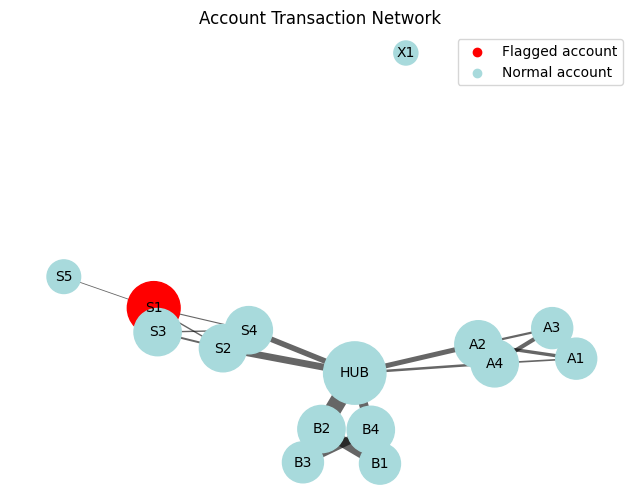

In [8]:
# TODO 1
pos = nx.spring_layout(G, seed=3)

node_colors = [
    "red" if G.nodes[node].get("flagged", False) else "#a8dadc"
    for node in G.nodes()
]

# TODO 2
degree_centrality = nx.degree_centrality(G)

node_sizes = [
    300 + 4000 * degree_centrality[node]
    for node in G.nodes()
]

# TODO 3
edge_widths = [
    G[u][v].get("amount", 1) / 5
    for u, v in G.edges()
]

plt.figure(figsize=(8, 6))

# TODO 4
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.6
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

# TODO 5
plt.scatter([], [], color="red", label="Flagged account")
plt.scatter([], [], color="#a8dadc", label="Normal account")

plt.legend()

plt.title("Account Transaction Network")
plt.axis("off")
plt.show()

**Reflection 4:** Look at your finished plot. Can you visually spot the suspicious cluster without having run any code in Parts 2–3? Is the node-link diagram already cluttered at just 15 nodes — what do you predict would happen at 500 accounts?

_(Write your answer here.)_

The suspicious cluster may be visually noticeable because flagged accounts, node sizes, and transaction strengths provide useful cues, but the diagram can still become difficult to interpret as the network grows. With 500 accounts, the node-link diagram would likely become heavily cluttered, so filtering, aggregation, or an adjacency matrix would be more useful for detailed investigation.

## Part 5 — Build and Read an Adjacency Matrix

**TODO:**
1. Compute the adjacency matrix for `G` using the **default** node order (`list(G.nodes())`).
2. Detect communities with `nx.algorithms.community.greedy_modularity_communities(G)`, and build a **reordered** node list where nodes are grouped by community.
3. Plot both matrices side by side (`plt.imshow`, `cmap="Reds"`).
4. Identify which lecture "pattern" (diagonal block / off-diagonal block / band / star-hub / bipartite / clique) the reordered matrix shows for the suspicious ring, and for `HUB`.

In [ ]:
# TODO 1: default-order adjacency matrix

nodes_default = list(G.nodes())

adj_default = nx.to_numpy_array(
    G,
    nodelist=nodes_default
)

print("Default-order adjacency matrix:")
print(adj_default)


# TODO 2: detect communities and create reordered node list

communities = list(
    nx.algorithms.community.greedy_modularity_communities(G)
)

nodes_reordered = []

for community in communities:
    nodes_reordered.extend(sorted(community))

adj_reordered = nx.to_numpy_array(
    G,
    nodelist=nodes_reordered
)


# TODO 3: plot both matrices side-by-side

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Default node order
axes[0].imshow(adj_default, cmap="Reds")
axes[0].set_title("Default Node Order")
axes[0].set_xlabel("Accounts")
axes[0].set_ylabel("Accounts")

# Reordered by community
axes[1].imshow(adj_reordered, cmap="Reds")
axes[1].set_title("Reordered by Community")
axes[1].set_xlabel("Accounts")
axes[1].set_ylabel("Accounts")

plt.tight_layout()
plt.show()

**Reflection 5:** Which pattern from the lecture (diagonal block, off-diagonal block, band, star/hub, bipartite, clique) best describes:
- (a) the S1–S2–S3–S4 ring in your reordered matrix?
- (b) the `HUB` account's row/column?

_(Write your answer here.)_

(a) The S1–S2–S3–S4 ring is best described as a diagonal block because the accounts in the same community have many connections with each other.

 (b) The HUB account is best described as a star/hub pattern because its row and column contain connections to many other accounts.

## Part 6 — The Decision (No Code)

Your manager only has time to look at **one** visualization before the compliance meeting, and the real dataset has **500 accounts**, not 15.

**Reflection 6 (final):** Write a 3–5 sentence recommendation to your manager. Your answer should:
- State whether you'd show them the node-link diagram, the adjacency matrix, or a NodeTrix-style hybrid, **at 500-account scale**.
- Justify it using at least one specific idea from the lecture (e.g. the "hairball effect," matrix scalability to ~1k nodes/1M edges, or NodeTrix combining both).
- Name which accounts you'd tell the compliance team to investigate first, and why.

_(Write your final recommendation here.)_


> At 500 accounts, I would show the **NodeTrix-style hybrid** because it combines the overall structure of a node-link diagram with the scalability and detail of an adjacency matrix. A node-link view at this scale can suffer from the **“hairball effect,”** while the matrix remains much easier to inspect for dense connections. I would ask the compliance team to investigate **S1, HUB, and the accounts identified as sharing S1’s device within 2 hops**, because these accounts show the strongest combination of existing suspicion, network connectivity, and shared attributes.
